Import Libraries

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset


In [25]:
df = pd.read_csv("/content/covid_19_clean_complete.csv")

 Select Required Columns


In [26]:
df = df[['Date', 'Country/Region', 'Confirmed',
         'Deaths', 'Recovered', 'Active']]

Data Cleaning


In [27]:
df['Date'] = pd.to_datetime(df['Date'])
df.drop_duplicates(inplace=True)
df.fillna(0, inplace=True)

Display Dataset

In [28]:
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (29995, 6)
        Date Country/Region  Confirmed  Deaths  Recovered  Active
0 2020-01-22    Afghanistan          0       0          0     0.0
1 2020-01-22        Albania          0       0          0     0.0
2 2020-01-22        Algeria          0       0          0     0.0
3 2020-01-22        Andorra          0       0          0     0.0
4 2020-01-22         Angola          0       0          0     0.0


Descriptive Statistics

In [29]:
print("\nTotal Confirmed Cases:", df['Confirmed'].sum())
print("Total Deaths:", df['Deaths'].sum())
print("Total Recovered:", df['Recovered'].sum())


Total Confirmed Cases: 168252426
Total Deaths: 11188904
Total Recovered: 51290117


Country Selection

In [30]:
country = "India"

country_df = df[df['Country/Region'] == country]

Line Chart

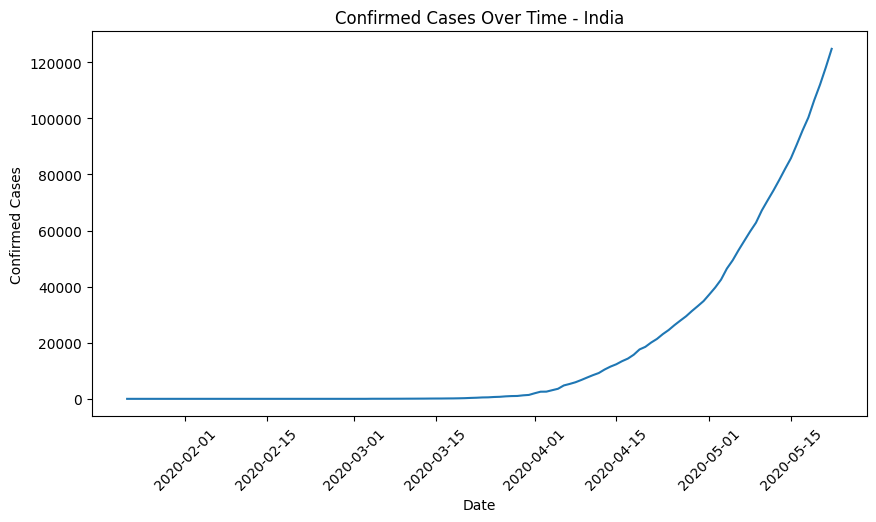

In [31]:
plt.figure(figsize=(10,5))
plt.plot(country_df['Date'],
         country_df['Confirmed'])

plt.title(f'Confirmed Cases Over Time - {country}')
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.show()

Top 10 Affected Countries

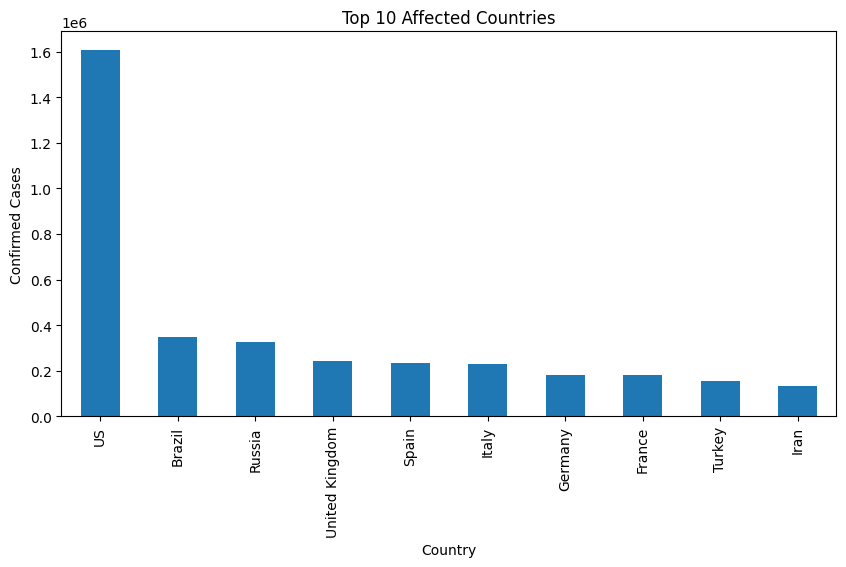

In [32]:
top_countries = (
    df.groupby('Country/Region')['Confirmed']
    .max()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')

plt.title("Top 10 Affected Countries")
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")
plt.show()

Pie Chart

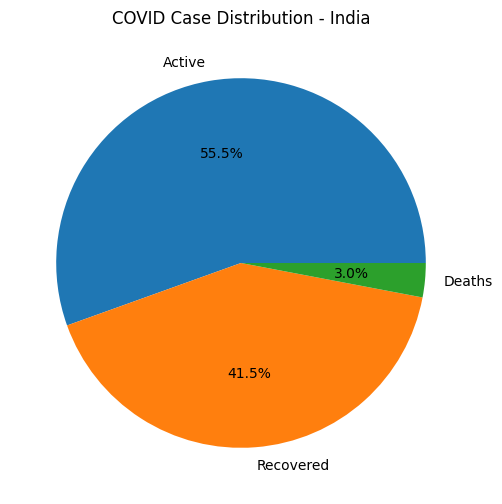

In [33]:
latest = country_df.iloc[-1]

plt.figure(figsize=(6,6))

plt.pie(
    [latest['Active'],
     latest['Recovered'],
     latest['Deaths']],
    labels=['Active','Recovered','Deaths'],
    autopct='%1.1f%%'
)

plt.title(f'COVID Case Distribution - {country}')
plt.show()

Scatter Plot

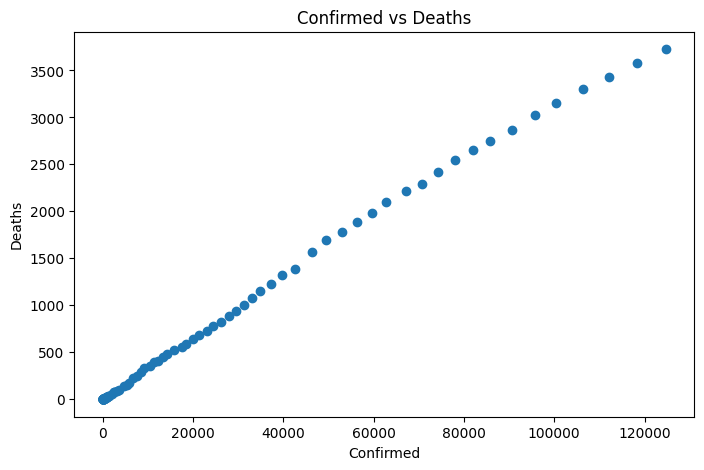

In [34]:
plt.figure(figsize=(8,5))

plt.scatter(
    country_df['Confirmed'],
    country_df['Deaths']
)

plt.title("Confirmed vs Deaths")
plt.xlabel("Confirmed")
plt.ylabel("Deaths")
plt.show()

Heatmap

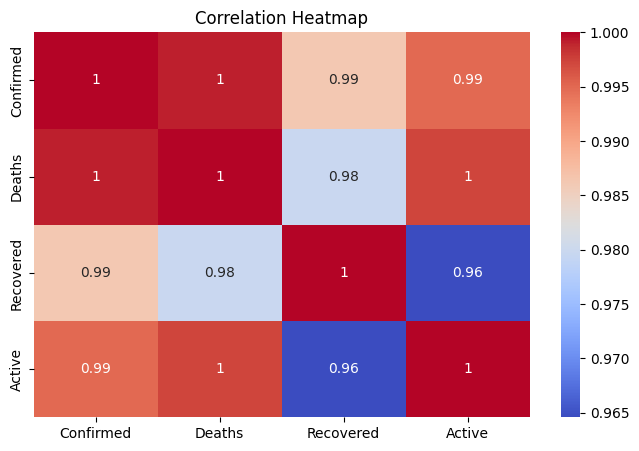

In [35]:
corr = country_df[
    ['Confirmed','Deaths',
     'Recovered','Active']
].corr()

plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()